In [45]:
pip install torch torchvision scikit-learn matplotlib pandas pillow

split

In [46]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil
import random

SOURCE = Path("/content/drive/MyDrive/dataset")
OUTPUT = Path("/content/drive/MyDrive/dataset/output")

CLASSES = ["landing_pad", "not_landing_pad"]
SEED = 42
IMAGE_EXTENSIONS = {".jpg"}

random.seed(SEED)

for class_name in CLASSES:
    class_dir = SOURCE / class_name

    if not class_dir.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {class_dir}")

    images = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if len(images) < 10:
        raise ValueError(
            f"Data kelas '{class_name}' terlalu sedikit: {len(images)} gambar"
        )

    train_images, remaining = train_test_split(
        images,
        test_size=0.20,
        random_state=SEED
    )

    val_images, test_images = train_test_split(
        remaining,
        test_size=0.50,
        random_state=SEED
    )

    splits = {
        "train": train_images,
        "val": val_images,
        "test": test_images
    }

    for split_name, files in splits.items():
        destination = OUTPUT / split_name / class_name
        destination.mkdir(parents=True, exist_ok=True)

        for src in files:
            shutil.copy2(src, destination / src.name)

        print(f"{split_name:5s} | {class_name:18s} | {len(files)} gambar")

print("\nPembagian dataset selesai.")

train | landing_pad        | 40 gambar
val   | landing_pad        | 5 gambar
test  | landing_pad        | 5 gambar
train | not_landing_pad    | 40 gambar
val   | not_landing_pad    | 5 gambar
test  | not_landing_pad    | 5 gambar

Pembagian dataset selesai.


train

In [47]:
from pathlib import Path
import csv
import random
import time

import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

DATA_DIR = Path("/content/drive/MyDrive/dataset/output")
RESULT_DIR = Path("/content/drive/MyDrive/dataset/hasil")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 2
EPOCHS = 10
BATCH_SIZE = 16
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

Device: cpu


In [48]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [49]:
train_data = datasets.ImageFolder(
    DATA_DIR / "train",
    transform=train_transform
)

val_data = datasets.ImageFolder(
    DATA_DIR / "val",
    transform=eval_transform
)

if train_data.classes != val_data.classes:
    raise ValueError("Urutan kelas train dan val berbeda.")

if len(train_data.classes) != NUM_CLASSES:
    raise ValueError("Jumlah kelas harus 2.")

if len(train_data) == 0 or len(val_data) == 0:
    raise ValueError("Dataset train atau val kosong.")

print("Urutan kelas:", train_data.classes)
print("Jumlah data train:", len(train_data))
print("Jumlah data val:", len(val_data))

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

Urutan kelas: ['landing_pad', 'not_landing_pad']
Jumlah data train: 80
Jumlah data val: 10


In [50]:
def create_model(mode):
    if mode not in ["feature", "partial", "scratch"]:
        raise ValueError(f"Mode tidak dikenal: {mode}")

    if mode == "scratch":
        # Model mulai dari bobot acak
        model = models.mobilenet_v3_small(weights=None)

        for p in model.parameters():
            p.requires_grad = True

    else:
        # Model menggunakan pretrained ImageNet
        model = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.DEFAULT
        )

        # Bekukan feature extractor
        for p in model.features.parameters():
            p.requires_grad = False

        # Latih classifier
        for p in model.classifier.parameters():
            p.requires_grad = True

        if mode == "partial":
            # Menggunakan dua modul terakhir pada feature extractor
            for p in model.features[-2:].parameters():
                p.requires_grad = True

    # Output dua kelas
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(
        in_features,
        NUM_CLASSES
    )

    return model

In [51]:
def create_optimizer(model, mode):
    if mode == "partial":
        feature_params = [
            p for p in model.features[-2:].parameters()
            if p.requires_grad
        ]

        classifier_params = [
            p for p in model.classifier.parameters()
            if p.requires_grad
        ]

        return Adam([
            {"params": feature_params, "lr": 1e-4},
            {"params": classifier_params, "lr": 1e-3}
        ])

    return Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-3
    )

In [52]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            total += labels.size(0)

    if total == 0:
        raise ValueError("Data evaluasi kosong.")

    return total_loss / total, correct / total

In [53]:
def train(mode):
    print(f"\n{'=' * 50}")
    print(f"Memulai mode: {mode}")
    print(f"{'=' * 50}")

    model = create_model(mode).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = create_optimizer(model, mode)

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    model_path = RESULT_DIR / f"mobilenet_{mode}.pth"
    csv_path = RESULT_DIR / f"history_{mode}.csv"

    best_val_acc = -1.0
    best_epoch = 0
    epoch_90 = None
    history = []

    start_time = time.perf_counter()

    for epoch in range(EPOCHS):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            total += labels.size(0)

        if total == 0:
            raise ValueError("Data training kosong.")

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc = evaluate(
            model, val_loader, criterion
        )

        scheduler.step()

        # Epoch pertama saat validation accuracy >= 90%
        if val_acc >= 0.90 and epoch_90 is None:
            epoch_90 = epoch + 1

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(
            f"[{mode}] Epoch {epoch + 1}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        # Simpan model dengan validation accuracy terbaik
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), model_path)

    training_seconds = time.perf_counter() - start_time

    # Simpan riwayat training setiap epoch
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "epoch", "train_loss", "train_acc",
                "val_loss", "val_acc"
            ]
        )
        writer.writeheader()
        writer.writerows(history)

    # Simpan hasil test
    summary_path = RESULT_DIR / "summary.csv"
    write_header = (
        not summary_path.exists()
        or summary_path.stat().st_size == 0
    )

    with open(summary_path, "a", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "model", "mode", "best_epoch",
                "best_val_acc", "epoch_90",
                "training_seconds"
            ]
        )

        if write_header:
            writer.writeheader()

        writer.writerow({
            "model": "MobileNetV3-Small",
            "mode": mode,
            "best_epoch": best_epoch,
            "best_val_acc": round(best_val_acc, 4),
            "epoch_90": epoch_90,
            "training_seconds": round(training_seconds, 2)
        })

    print(f"\nCheckpoint: {model_path}")
    print(f"Best epoch: {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print(f"Epoch pertama val_acc >= 90%: {epoch_90}")
    print(f"Waktu training: {training_seconds:.2f} detik")
    print(f"Riwayat: {csv_path}")

In [54]:
train("feature")


Memulai mode: feature
[feature] Epoch 1/10 | train_loss=0.4682 | train_acc=0.7375 | val_loss=0.4309 | val_acc=0.8000
[feature] Epoch 2/10 | train_loss=0.2417 | train_acc=0.9375 | val_loss=0.3519 | val_acc=0.8000
[feature] Epoch 3/10 | train_loss=0.1022 | train_acc=1.0000 | val_loss=0.2909 | val_acc=0.8000
[feature] Epoch 4/10 | train_loss=0.0585 | train_acc=0.9875 | val_loss=0.2919 | val_acc=0.8000
[feature] Epoch 5/10 | train_loss=0.0944 | train_acc=0.9750 | val_loss=0.2963 | val_acc=0.8000
[feature] Epoch 6/10 | train_loss=0.0435 | train_acc=0.9875 | val_loss=0.2187 | val_acc=1.0000
[feature] Epoch 7/10 | train_loss=0.1022 | train_acc=0.9500 | val_loss=0.1727 | val_acc=1.0000
[feature] Epoch 8/10 | train_loss=0.0537 | train_acc=0.9875 | val_loss=0.1523 | val_acc=1.0000
[feature] Epoch 9/10 | train_loss=0.0371 | train_acc=0.9875 | val_loss=0.1266 | val_acc=1.0000
[feature] Epoch 10/10 | train_loss=0.1157 | train_acc=0.9625 | val_loss=0.1029 | val_acc=1.0000

Checkpoint: /content/driv

In [55]:
train("partial")


Memulai mode: partial
[partial] Epoch 1/10 | train_loss=0.6038 | train_acc=0.6125 | val_loss=0.6402 | val_acc=0.5000
[partial] Epoch 2/10 | train_loss=0.2041 | train_acc=0.9500 | val_loss=0.6047 | val_acc=0.5000
[partial] Epoch 3/10 | train_loss=0.1334 | train_acc=0.9500 | val_loss=0.4348 | val_acc=0.6000
[partial] Epoch 4/10 | train_loss=0.1692 | train_acc=0.9125 | val_loss=0.3027 | val_acc=0.9000
[partial] Epoch 5/10 | train_loss=0.1055 | train_acc=0.9875 | val_loss=0.2982 | val_acc=0.9000
[partial] Epoch 6/10 | train_loss=0.0451 | train_acc=0.9875 | val_loss=0.2587 | val_acc=1.0000
[partial] Epoch 7/10 | train_loss=0.0751 | train_acc=0.9875 | val_loss=0.1750 | val_acc=1.0000
[partial] Epoch 8/10 | train_loss=0.0227 | train_acc=1.0000 | val_loss=0.1296 | val_acc=1.0000
[partial] Epoch 9/10 | train_loss=0.0800 | train_acc=0.9750 | val_loss=0.1012 | val_acc=1.0000
[partial] Epoch 10/10 | train_loss=0.0396 | train_acc=1.0000 | val_loss=0.0841 | val_acc=1.0000

Checkpoint: /content/driv

In [56]:
train("scratch")


Memulai mode: scratch
[scratch] Epoch 1/10 | train_loss=0.6282 | train_acc=0.5875 | val_loss=0.6934 | val_acc=0.5000
[scratch] Epoch 2/10 | train_loss=0.6830 | train_acc=0.7125 | val_loss=0.6936 | val_acc=0.5000
[scratch] Epoch 3/10 | train_loss=0.5075 | train_acc=0.7625 | val_loss=0.6936 | val_acc=0.5000
[scratch] Epoch 4/10 | train_loss=0.2175 | train_acc=0.9500 | val_loss=0.6946 | val_acc=0.5000
[scratch] Epoch 5/10 | train_loss=0.1219 | train_acc=0.9625 | val_loss=0.6961 | val_acc=0.5000
[scratch] Epoch 6/10 | train_loss=0.0482 | train_acc=0.9750 | val_loss=0.6962 | val_acc=0.5000
[scratch] Epoch 7/10 | train_loss=0.3568 | train_acc=0.8750 | val_loss=0.6948 | val_acc=0.5000
[scratch] Epoch 8/10 | train_loss=0.2552 | train_acc=0.9125 | val_loss=0.6947 | val_acc=0.5000
[scratch] Epoch 9/10 | train_loss=0.0670 | train_acc=0.9750 | val_loss=0.6947 | val_acc=0.5000
[scratch] Epoch 10/10 | train_loss=0.0503 | train_acc=0.9875 | val_loss=0.6948 | val_acc=0.5000

Checkpoint: /content/driv

In [57]:
import pandas as pd

summary = pd.read_csv(RESULT_DIR / "summary.csv")
display(summary)

,model,mode,best_epoch,best_val_acc,epoch_90,training_seconds
0,MobileNetV3-Small,feature,6,1.0,6.0,31.29
1,MobileNetV3-Small,partial,6,1.0,4.0,29.42
2,MobileNetV3-Small,scratch,1,0.5,NaN,58.28


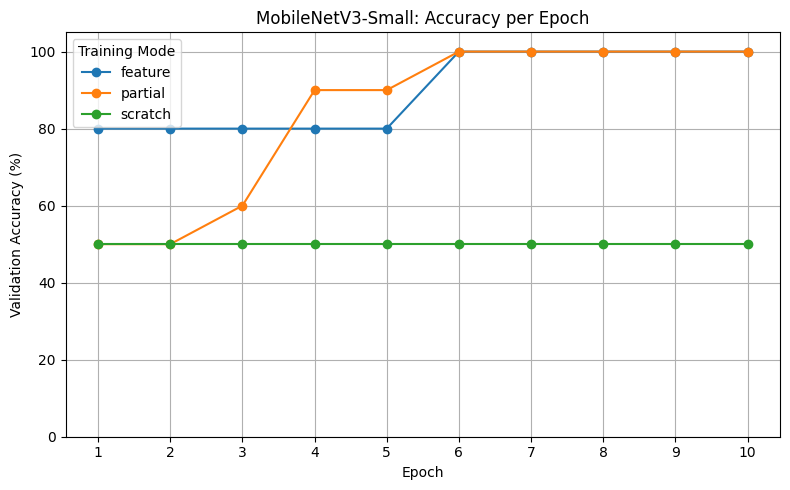

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

result_dir = "/content/drive/MyDrive/dataset/hasil"

plt.figure(figsize=(8, 5))

for mode in ["feature", "partial", "scratch"]:
    csv_path = f"{result_dir}/history_{mode}.csv"
    df = pd.read_csv(csv_path)

    plt.plot(
        df["epoch"],
        df["val_acc"] * 100,
        marker="o",
        label=mode
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("MobileNetV3-Small: Accuracy per Epoch")
plt.xticks(range(1, 11))
plt.ylim(0, 105)
plt.grid(True)
plt.legend(title="Training Mode")
plt.tight_layout()
plt.show()

latency

In [66]:

import time
import torch
import torch.nn as nn
import pandas as pd
from torchvision import models, transforms
from PIL import Image

RESULT_DIR = "/content/drive/MyDrive/dataset/hasil"
IMAGE_PATH = "/content/drive/MyDrive/dataset/output/test/landing_pad/landing_pad_10.jpg"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

image = Image.open(IMAGE_PATH).convert("RGB")
x = transform(image).unsqueeze(0).to(device)

results = []

for mode in ["feature", "partial", "scratch"]:

    model_path = f"{RESULT_DIR}/mobilenet_{mode}.pth"

    model = models.mobilenet_v3_small(weights=None)
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features, 2
    )

    model.load_state_dict(
        torch.load(model_path, map_location=device)
    )
    model = model.to(device).eval()

    with torch.no_grad():
        for _ in range(20):
            model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()

    times = []

    with torch.no_grad():
        for _ in range(100):
            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()
            model(x)

            if device.type == "cuda":
                torch.cuda.synchronize()

            times.append((time.perf_counter() - start) * 1000)

    avg_latency = sum(times) / len(times)

    results.append({
        "Model": "MobileNetV3-Small",
        "Mode": mode,
        "Device": str(device),
        "Latency (ms)": round(avg_latency, 3),
        "FPS": round(1000 / avg_latency, 2)
    })

    print(f"{mode}: selesai diuji")

    del model

latency_df = pd.DataFrame(results)
display(latency_df)

latency_df.to_csv(
    f"{RESULT_DIR}/latency_results.csv",
    index=False
)

print("Hasil disimpan ke latency_results.csv")

feature: selesai diuji
partial: selesai diuji
scratch: selesai diuji


,Model,Mode,Device,Latency (ms),FPS
0,MobileNetV3-Small,feature,cpu,15.764,63.43
1,MobileNetV3-Small,partial,cpu,19.147,52.23
2,MobileNetV3-Small,scratch,cpu,16.363,61.11


Hasil disimpan ke latency_results.csv


test

In [62]:
from torchvision import datasets
from torch.utils.data import DataLoader

test_dataset = datasets.ImageFolder(
    DATA_DIR / "test",
    transform=eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Jumlah gambar test:", len(test_dataset))
print("Kelas:", test_dataset.classes)

Jumlah gambar test: 10
Kelas: ['landing_pad', 'not_landing_pad']


In [69]:
import torch
import pandas as pd

RESULT_DIR = Path("/content/drive/MyDrive/dataset/hasil")

test_results = []

for mode in ["feature", "partial", "scratch"]:
    print(f"Menguji model: {mode}")

    model = create_model(mode).to(device)
    model.load_state_dict(
        torch.load(
            RESULT_DIR / f"mobilenet_{mode}.pth",
            map_location=device
        )
    )
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    if total == 0:
        raise ValueError("Dataset test kosong!")

    accuracy = 100 * correct / total

    test_results.append({
        "Model": "MobileNetV3-Small",
        "Mode": mode,
        "Correct": correct,
        "Total Test Images": total,
        "Test Accuracy (%)": round(accuracy, 2)
    })

    print(f"Hasil: {correct}/{total} gambar benar")
    print(f"Test Accuracy: {accuracy:.2f}%\n")

    del model

test_df = pd.DataFrame(test_results)
display(test_df)

test_df.to_csv(
    RESULT_DIR / "test_results.csv",
    index=False
)

print("Hasil tersimpan di:", RESULT_DIR / "test_results.csv")

Menguji model: feature
Hasil: 10/10 gambar benar
Test Accuracy: 100.00%

Menguji model: partial
Hasil: 10/10 gambar benar
Test Accuracy: 100.00%

Menguji model: scratch
Hasil: 5/10 gambar benar
Test Accuracy: 50.00%



,Model,Mode,Correct,Total Test Images,Test Accuracy (%)
0,MobileNetV3-Small,feature,10,10,100.0
1,MobileNetV3-Small,partial,10,10,100.0
2,MobileNetV3-Small,scratch,5,10,50.0


Hasil tersimpan di: /content/drive/MyDrive/dataset/hasil/test_results.csv


In [70]:
import torch
import pandas as pd

model = create_model("scratch").to(device)
model.load_state_dict(
    torch.load(
        RESULT_DIR / "mobilenet_scratch.pth",
        map_location=device
    )
)
model.eval()

results = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu()

        for i in range(len(labels)):
            actual = test_dataset.classes[labels[i].item()]
            predicted = test_dataset.classes[predictions[i].item()]

            results.append({
                "Actual": actual,
                "Predicted": predicted,
                "Status": "Benar" if actual == predicted else "Salah"
            })

display(pd.DataFrame(results))

,Actual,Predicted,Status
0,landing_pad,not_landing_pad,Salah
1,landing_pad,not_landing_pad,Salah
2,landing_pad,not_landing_pad,Salah
3,landing_pad,not_landing_pad,Salah
4,landing_pad,not_landing_pad,Salah
5,not_landing_pad,not_landing_pad,Benar
6,not_landing_pad,not_landing_pad,Benar
7,not_landing_pad,not_landing_pad,Benar
8,not_landing_pad,not_landing_pad,Benar
9,not_landing_pad,not_landing_pad,Benar
